# 08 · Tendências por categoria, produto e item de configuração

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autores:** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Criado em:** 30/09/2026 · **Atualizado em:** 30/09/2026

Tendência por categoria, produto e item de configuração, as três dimensões que o enunciado da Locaweb cita no objetivo de identificar tendências, além da prioridade. O notebook mede, para cada dimensão, onde as violações de OLA se concentram e o que o volume mensal mostra até 30/09/2025.

A restrição que define o desenho é o tamanho do dado: 188 violações na janela, espalhadas por até 3.774 valores. Uma série de violações por mês e por valor tem quase sempre 0, 1 ou 2 ocorrências, e uma tendência sobre isso é ruído.

**Janela:** incidentes elegíveis ao KPI abertos entre 01/01/2025 e 30/09/2025, acompanhando o corte
da aplicação.

**Entrada:** `data/interim/incidentes_kpi.parquet`, gerado pelo notebook 02.
**Saída:** figuras em `notebooks/figures/08_tendencias/`, `data/interim/08_tendencias_ranking.parquet` e
`data/interim/08_tendencias_mensal.parquet`.
**Bibliotecas:** pandas, numpy, matplotlib (Python 3.11+).

In [1]:
# Stdlib
import warnings
from pathlib import Path

# Third-party
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

## 1. Setup

Estilo dos gráficos, caminhos, o mapeamento entre o nome de cada dimensão e a coluna da base, o piso de 200 incidentes (o mesmo do notebook 07) e as funções de formatação.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'
FIG_DIR = RAIZ / 'notebooks' / 'figures' / '08_tendencias'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Nome de exibição -> coluna da base
DIMENSOES = {'categoria': 'Categoria', 'produto': 'Produto',
             'item de configuração': 'Item de configuração'}
MINIMO_INCIDENTES = 200      # mesmo piso do notebook 07, para a variação de volume ter base
TOPO = 10                    # quantos valores de cada dimensão entram nas tabelas

def fmt(x, casas=2):
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

A janela segue o relógio da aplicação, parado em 01/10/2025 às 15h: nada de outubro em diante entra, nem no volume nem nas violações. As três colunas de dimensão têm valores ausentes, que permanecem ausentes e não viram uma categoria chamada "nan".

In [3]:
# O relógio da aplicação está parado em 01/10/2025 às 15h e ela lê a saída deste notebook.
# Nada de outubro em diante entra na janela, nem na contagem de incidentes nem na de violações.
CORTE = pd.Timestamp('2025-10-01')

df_kpi = pd.read_parquet(PARQUET)
df_kpi['violou'] = (df_kpi['KPI Violado?'] == 'SIM').astype(int)
df_kpi['pri'] = 'P' + df_kpi['Prioridade'].astype(str).str[0]

df_ano = df_kpi[(df_kpi['ano'] == 2025) & (df_kpi['dia'] < CORTE)].copy()
for coluna in DIMENSOES.values():
    df_ano[coluna] = df_ano[coluna].astype('string')   # o ausente segue ausente, sem virar o valor "nan"

assert set(df_ano['pri']) == {'P2', 'P3'}, 'a base elegível deveria ter só P2 e P3 em 2025'
print(f'incidentes na janela: {fmt_int(len(df_ano))}')
print(f'violações na janela:  {fmt_int(df_ano["violou"].sum())}')
print(df_ano.groupby('pri')['violou'].agg(incidentes='size', violacoes='sum').to_string())
ausentes = pd.DataFrame({
    nome: {'incidentes sem o campo': int(df_ano[col].isna().sum()),
           'violações entre eles': int(df_ano.loc[df_ano[col].isna(), 'violou'].sum())}
    for nome, col in DIMENSOES.items()}).T
print(ausentes.to_string())

incidentes na janela: 19.973
violações na janela:  188
     incidentes  violacoes
pri                       
P2         3911         33
P3        16062        155
                      incidentes sem o campo  violações entre eles
categoria                                 22                     0
produto                                   20                     0
item de configuração                      60                     0


A janela tem 19.973 incidentes e 188 violações: 3.911 incidentes e 33 violações na P2, 16.062 incidentes e 155 violações na P3. Faltam a categoria em 22 incidentes, o produto em 20 e o item de configuração em 60, e nenhum deles violou o OLA.

## 3. Visão geral

Cardinalidade e concentração de cada dimensão: quantos valores distintos existem, quantos têm alguma violação e quanto das 188 violações ficam nos 10 valores que mais violaram.

In [4]:
def ordena(serie):
    """Maior primeiro, com desempate pelo nome, para o ranking ser reprodutível."""
    return serie.sort_index().sort_values(ascending=False, kind='mergesort')

def resume(coluna):
    g = df_ano.groupby(coluna).agg(incidentes=('violou', 'size'), violacoes=('violou', 'sum'))
    topo = ordena(g['violacoes']).head(TOPO).sum()
    return pd.Series({
        'valores distintos': len(g),
        'com alguma violação': int((g['violacoes'] > 0).sum()),
        f'violações nos {TOPO} primeiros': int(topo),
        '% das violações': round(100 * topo / g['violacoes'].sum(), 1),
        f'valores com {MINIMO_INCIDENTES}+ incidentes': int((g['incidentes'] >= MINIMO_INCIDENTES).sum()),
    })

resumo = pd.DataFrame({nome: resume(col) for nome, col in DIMENSOES.items()}).T
print(resumo.to_string())

                      valores distintos  com alguma violação  violações nos 10 primeiros  % das violações  valores com 200+ incidentes
categoria                         113.0                 40.0                       134.0             71.3                         17.0
produto                            45.0                 22.0                       162.0             86.2                         15.0
item de configuração             3774.0                106.0                        82.0             43.6                         10.0


As três dimensões têm cardinalidades muito diferentes: 113 categorias, 45 produtos e 3.774 itens de configuração, dos quais 40, 22 e 106 têm alguma violação. **Os 10 produtos com mais violações concentram 86,2% delas, as 10 categorias 71,3% e os 10 itens de configuração 43,6%.** Só 17 categorias, 15 produtos e 10 itens de configuração têm 200 incidentes ou mais na janela.

## 4. Análise

### 4.1 Concentração das violações

A curva de concentração mostra quantos valores de cada dimensão são necessários para reunir a maior parte das violações. O eixo horizontal é logarítmico porque o item de configuração tem dezenas de vezes mais valores que o produto.

% acumulado das violações, pelos N valores com mais violações:
                      1 primeiros  5 primeiros  10 primeiros  30 primeiros  100 primeiros
categoria                    16.5         54.8          71.3          94.7          100.0
produto                      25.5         70.2          86.2         100.0          100.0
item de configuração         11.2         34.0          43.6          59.6           96.8

valores necessários para reunir 80% das violações:
                      valores  valores para 80%  % dos valores
categoria               113.0              15.0           13.3
produto                  45.0               8.0           17.8
item de configuração   3774.0              69.0            1.8


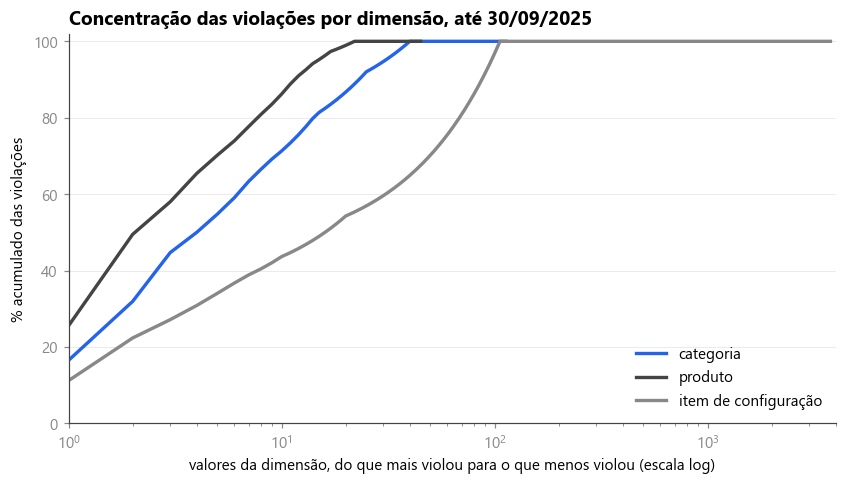

In [5]:
def curva(coluna):
    v = ordena(df_ano.groupby(coluna)['violou'].sum())
    return v.cumsum() / v.sum()

PONTOS = [1, 5, 10, 30, 100]
linhas = {}
for nome, coluna in DIMENSOES.items():
    c = curva(coluna)
    linhas[nome] = {f'{n} primeiros': round(100 * c.iloc[min(n, len(c)) - 1], 1) for n in PONTOS}
print('% acumulado das violações, pelos N valores com mais violações:')
print(pd.DataFrame(linhas).T.to_string())

# Regra de Pareto: quantos valores são necessários para reunir 80% das violações
linhas_80 = {}
for nome, coluna in DIMENSOES.items():
    acumulado = curva(coluna)
    total_valores = df_ano[coluna].nunique()
    k80 = int((acumulado.to_numpy() >= 0.80).argmax()) + 1
    linhas_80[nome] = {'valores': total_valores, 'valores para 80%': k80,
                       '% dos valores': round(100 * k80 / total_valores, 1)}
print()
print('valores necessários para reunir 80% das violações:')
print(pd.DataFrame(linhas_80).T.to_string())

fig, ax = plt.subplots(figsize=(9, 4.6))
for (nome, coluna), cor in zip(DIMENSOES.items(), [COR['accent'], COR['cinza_esc'], COR['cinza']]):
    c = curva(coluna)
    ax.plot(np.arange(1, len(c) + 1), 100 * c.values, color=cor, linewidth=2.2, label=nome)
ax.set_xscale('log')
ax.set_xlim(1, 4000)
ax.set_ylim(0, 102)
ax.set_xlabel('valores da dimensão, do que mais violou para o que menos violou (escala log)')
ax.set_ylabel('% acumulado das violações')
ax.set_title('Concentração das violações por dimensão, até 30/09/2025')
ax.grid(axis='x', visible=False)
ax.legend(loc='lower right')
salvar_fig(fig, 'concentracao')
plt.show()

O produto com mais violações reúne 25,5% de todas elas, contra 16,5% da categoria e 11,2% do item de configuração. Com 5 valores, o produto chega a 70,2%, a categoria a 54,8% e o item de configuração a 34,0%. **A regra de Pareto, que costuma apontar cerca de 20% das causas para 80% dos efeitos, se confirma nas três dimensões:** 80% das violações estão em 8 dos 45 produtos (17,8%), em 15 das 113 categorias (13,3%) e em 69 dos 3.774 itens de configuração (1,8%). Os 10 itens do topo reúnem menos (43,6%) porque o universo é de milhares de valores, e as violações se espalham por mais deles.

### 4.2 Tendência do volume

O volume mensal é medido para os 10 valores de cada dimensão com mais violações. A tendência é a média mensal de julho a setembro contra a de janeiro a junho, que acompanha a comparação de trimestre do notebook 07 e deixa de fora qualquer mês posterior ao corte.

In [6]:
MESES = list(range(1, 10))

def topo_por_violacao(coluna):
    return list(ordena(df_ano.groupby(coluna)['violou'].sum()).head(TOPO).index)

def mensal(coluna, valores, medida):
    """Tabela valor x mês (1 a 9) com o volume ou a soma de violações."""
    base = df_ano[df_ano[coluna].isin(valores)]
    agg = 'size' if medida == 'volume' else 'sum'
    tabela = base.pivot_table(index=coluna, columns='mes', values='violou', aggfunc=agg, fill_value=0)
    return tabela.reindex(index=valores, columns=MESES, fill_value=0)

def variacao_volume(tabela):
    """Média mensal de julho a setembro contra a de janeiro a junho."""
    return tabela[[7, 8, 9]].mean(axis=1) / tabela[[1, 2, 3, 4, 5, 6]].mean(axis=1) - 1

for nome, coluna in DIMENSOES.items():
    valores = topo_por_violacao(coluna)
    vol = mensal(coluna, valores, 'volume')
    vista = vol.copy()
    vista['variação %'] = (100 * variacao_volume(vol)).round(0)
    print(f'{nome}: volume mensal dos {TOPO} valores com mais violações')
    print(vista.to_string())
    print()

categoria: volume mensal dos 10 valores com mais violações
mes          1    2    3    4    5    6    7    8    9  variação %
Categoria                                                         
cat31      288  225  120  127  179  167  236  197  242        22.0
cat85      272  281  312  328  454  371  334  285  247       -14.0
cat71      271  330  255  274  244  262  317  344  343        23.0
cat103      61   66   65   74   78   54   55   39   29       -38.0
cat77      116  128   74   95   87   87  117  185  246        87.0
cat73      145   81  111  119  155  145   80   97   90       -29.0
cat91      108   93  132  140  131  120   92   71   83       -32.0
cat24       39   25   25   22   50   32   31   38   28         1.0
cat88        6    4    2    3    1    7   13    7    5       117.0
cat102      36   33   31   25   40   26   32   39   34        10.0

produto: volume mensal dos 10 valores com mais violações
mes        1    2    3    4    5    6    7    8    9  variação %
Produto       

O volume tem base para tendência em produto e categoria. Entre os produtos, `lsin` subiu 38%, de 182 incidentes em março para 395 em setembro, e `lgoa` caiu 43%. Entre as categorias, `cat77` subiu 87% e `cat103` caiu 38%. **Em item de configuração a leitura é menos firme:** `IC01139` aparece com alta de 81%, mas são 5 incidentes em janeiro e 9 em setembro, e `IC00840`, que está entre os dois itens com mais violações, tem de 4 a 11 incidentes por mês.

### 4.3 O que as violações sustentam

Para saber se a tendência das violações pode ser lida mês a mês, a célula mede, nos 10 valores do topo, quantos meses ficam sem nenhuma violação e qual é o máximo em um mês, e compara com o volume. O gráfico mostra o volume dos 5 valores com mais violações em cada dimensão.

                      meses sem violação (%)  máximo em um mês  mediana das violações por mês  meses sem incidente (%)  mediana do volume por mês
dimensão                                                                                                                                         
categoria                               36.0                10                            1.0                      0.0                       92.5
produto                                 36.0                10                            1.0                      0.0                      103.5
item de configuração                    51.0                 5                            0.0                      0.0                       25.5


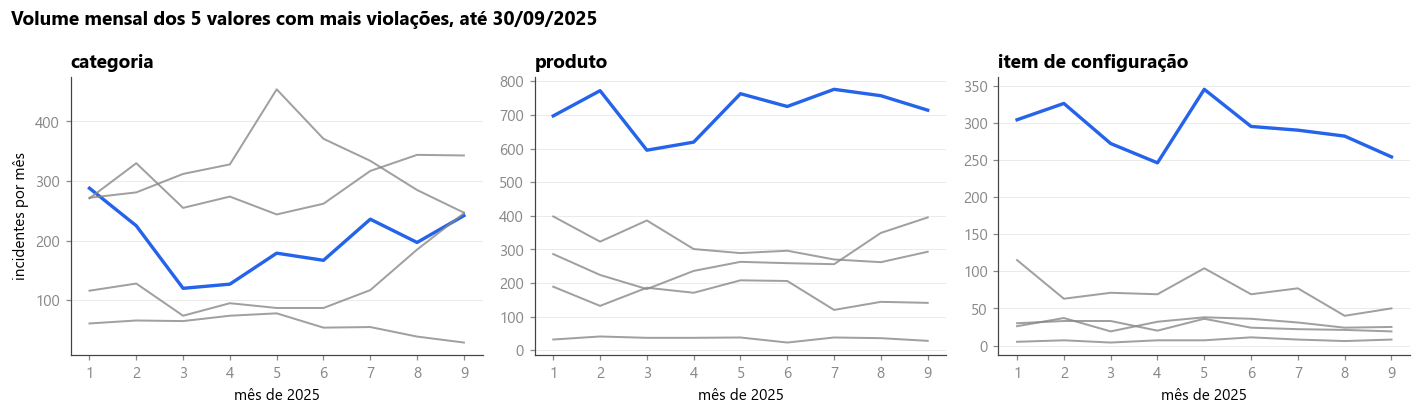

In [7]:
linhas = []
for nome, coluna in DIMENSOES.items():
    valores = topo_por_violacao(coluna)
    vio = mensal(coluna, valores, 'violacoes')
    vol = mensal(coluna, valores, 'volume')
    linhas.append({
        'dimensão': nome,
        'meses sem violação (%)': round(100 * (vio == 0).to_numpy().mean(), 0),
        'máximo em um mês': int(vio.to_numpy().max()),
        'mediana das violações por mês': float(np.median(vio.to_numpy())),
        'meses sem incidente (%)': round(100 * (vol == 0).to_numpy().mean(), 0),
        'mediana do volume por mês': float(np.median(vol.to_numpy())),
    })
print(pd.DataFrame(linhas).set_index('dimensão').to_string())

fig, eixos = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
for ax, (nome, coluna) in zip(eixos, DIMENSOES.items()):
    valores = topo_por_violacao(coluna)[:5]
    vol = mensal(coluna, valores, 'volume')
    for i, v in enumerate(valores):
        ax.plot(MESES, vol.loc[v].values, color=COR['accent'] if i == 0 else COR['cinza'],
                linewidth=2.2 if i == 0 else 1.3, alpha=1 if i == 0 else 0.8)
    ax.set_title(nome)
    ax.set_xticks(MESES)
    ax.set_xlabel('mês de 2025')
eixos[0].set_ylabel('incidentes por mês')
fig.suptitle('Volume mensal dos 5 valores com mais violações, até 30/09/2025', x=0.01, ha='left',
             fontweight='bold', fontsize=12.5)
fig.tight_layout()
salvar_fig(fig, 'volume_mensal_top5')
plt.show()

As violações mês a mês são esparsas. Nos 10 valores do topo, 36% dos meses de categoria e de produto não têm nenhuma violação, e 51% dos meses de item de configuração. A mediana é de 1 violação por mês em categoria e produto e de 0 em item de configuração, com máximo de 10, 10 e 5. O volume, no mesmo recorte, nunca fica em zero e tem mediana de 92,5, 103,5 e 25,5 incidentes por mês. **A série de violações não sustenta uma linha de tendência por valor, e a de volume sustenta.** Para as violações, o que o dado permite é a contagem acumulada na janela, com a comparação de trimestres feita sobre contagens que continuam visíveis.

### 4.4 P2 e P3 lado a lado

As tabelas repetem o topo de cada dimensão com incidentes e violações separados por prioridade. A taxa de violação não entra: com 33 violações de P2 na janela inteira, a taxa por valor seria calculada sobre bases de poucos incidentes.

In [8]:
for nome, coluna in DIMENSOES.items():
    valores = topo_por_violacao(coluna)
    g = df_ano[df_ano[coluna].isin(valores)].groupby([coluna, 'pri'])['violou'].agg(['size', 'sum'])
    p = g.unstack('pri').reindex(valores).fillna(0).astype(int)
    p.columns = [f'{"incid" if a == "size" else "viol"}_{b}' for a, b in p.columns]
    p = p[['incid_P2', 'viol_P2', 'incid_P3', 'viol_P3']]
    p['viol_total'] = p['viol_P2'] + p['viol_P3']
    print(f'{nome}: {TOPO} valores com mais violações, P2 e P3 lado a lado')
    print(p.to_string())
    print()

categoria: 10 valores com mais violações, P2 e P3 lado a lado
           incid_P2  viol_P2  incid_P3  viol_P3  viol_total
Categoria                                                  
cat31            14        1      1767       30          31
cat85            85        4      2799       25          29
cat71           776        3      1864       21          24
cat103            3        0       518       10          10
cat77           515        8       620        1           9
cat73           542        1       481        7           8
cat91            11        1       959        7           8
cat24            31        0       259        6           6
cat88             5        1        43        4           5
cat102           23        0       273        4           4

produto: 10 valores com mais violações, P2 e P3 lado a lado
         incid_P2  viol_P2  incid_P3  viol_P3  viol_total
Produto                                                  
lhco          737        4      5681     

A P3 responde pela maior parte das violações do topo, mas a P2 se concentra em poucos valores. `lsin` tem 12 das 33 violações de P2 da janela, contra 4 do `lhco`, que lidera o total com 48. Em categoria, `cat77` tem 8 das 33 de P2 e só 1 de P3. `IC00349` e `IC00840` têm 21 violações cada, todas de P3, sem nenhuma de P2. **O total por valor esconde onde está a violação de P2.**

### 4.5 Saída para a aplicação

Duas tabelas para a aplicação. O ranking traz, por dimensão e valor, incidentes e violações totais e por prioridade, a posição e a variação de volume, calculada só para valores com 200 incidentes ou mais. A série mensal traz incidentes e violações por valor, mês e prioridade. Entram os valores que violaram ao menos uma vez ou que passam do piso de volume, e a janela fica gravada no atributo de cada tabela.

In [9]:
def monta_mensal(coluna, nome):
    g = (df_ano.groupby([coluna, 'mes', 'pri'])['violou']
         .agg(incidentes='size', violacoes='sum').reset_index()
         .rename(columns={coluna: 'valor'}))
    g.insert(0, 'dimensao', nome)
    return g

def monta_ranking(coluna, nome):
    g = df_ano.groupby(coluna).agg(incidentes=('violou', 'size'), violacoes=('violou', 'sum'))
    for pri in ('P2', 'P3'):
        s = df_ano[df_ano['pri'] == pri].groupby(coluna)['violou'].agg(['size', 'sum'])
        g[f'incidentes_{pri.lower()}'] = s['size'].reindex(g.index).fillna(0).astype(int)
        g[f'violacoes_{pri.lower()}'] = s['sum'].reindex(g.index).fillna(0).astype(int)
    vol = df_ano.pivot_table(index=coluna, columns='mes', values='violou', aggfunc='size', fill_value=0)
    vol = vol.reindex(columns=MESES, fill_value=0)
    g['variacao_volume'] = variacao_volume(vol).reindex(g.index)
    g.loc[g['incidentes'] < MINIMO_INCIDENTES, 'variacao_volume'] = np.nan   # base pequena demais
    g = g.reset_index().rename(columns={coluna: 'valor'})
    g = g.sort_values(['violacoes', 'incidentes', 'valor'], ascending=[False, False, True], kind='mergesort')
    g.insert(0, 'posicao', np.arange(1, len(g) + 1))
    g.insert(0, 'dimensao', nome)
    # só entram valores que violaram alguma vez ou que têm volume para o ranking de volume
    return g[(g['violacoes'] > 0) | (g['incidentes'] >= MINIMO_INCIDENTES)]

df_mensal = pd.concat([monta_mensal(c, n) for n, c in DIMENSOES.items()], ignore_index=True)
df_ranking = pd.concat([monta_ranking(c, n) for n, c in DIMENSOES.items()], ignore_index=True)
for tabela in (df_mensal, df_ranking):
    tabela.attrs['janela'] = '2025-01-01 a 2025-09-30'

# as parcelas precisam fechar com o total da janela
for nome, coluna in DIMENSOES.items():
    parte = df_mensal[df_mensal['dimensao'] == nome]
    com_valor = df_ano[coluna].notna()
    assert parte['incidentes'].sum() == com_valor.sum(), f'{nome}: o mensal não soma a janela'
    assert parte['violacoes'].sum() == df_ano.loc[com_valor, 'violou'].sum()

destino_ranking = RAIZ / 'data' / 'interim' / '08_tendencias_ranking.parquet'
destino_mensal = RAIZ / 'data' / 'interim' / '08_tendencias_mensal.parquet'
df_ranking.to_parquet(destino_ranking, index=False)
df_mensal.to_parquet(destino_mensal, index=False)

for origem, destino in ((df_ranking, destino_ranking), (df_mensal, destino_mensal)):
    conferencia = pd.read_parquet(destino)
    assert conferencia.shape == origem.shape
    assert (conferencia.dtypes == origem.dtypes).all()
print(f'ranking: {fmt_int(len(df_ranking))} linhas | mensal: {fmt_int(len(df_mensal))} linhas')
print(df_ranking.groupby('dimensao').size().to_string())

ranking: 173 linhas | mensal: 8.947 linhas
dimensao
categoria                44
item de configuração    107
produto                  22


## 5. Conclusão

A tendência por categoria, produto e item de configuração pode ser mostrada até 30/09/2025 em duas camadas com robustez diferente. A de volume é firme: os valores do topo têm incidentes em todos os meses, e a variação entre o terceiro trimestre e o primeiro semestre separa os que crescem (`lsin`, 38%; `cat77`, 87%) dos que caem (`lgoa`, 43%; `cat103`, 38%).

A camada de violações é outra. As 188 violações ficam em 40 categorias, 22 produtos e 106 itens de configuração, e isso deixa séries mensais de 0, 1 ou 2 ocorrências. O que o dado sustenta é a concentração, com os 10 produtos em 86,2% das violações e as 10 categorias em 71,3%, e a separação por prioridade. **A regra de Pareto vale nas três dimensões, com 80% das violações em 17,8% dos produtos, 13,3% das categorias e 1,8% dos itens de configuração, e o dado não permite afirmar uma tendência de violações por valor individual.** Nos itens de configuração os 10 primeiros reúnem só 43,6%, porque as violações se espalham por mais valores. A recorrência de violação por item de configuração já foi medida no notebook 05.

As duas tabelas gravadas cobrem P2 e P3 e carregam a janela no atributo. A variação de volume existe para 17 categorias, 15 produtos e 10 itens de configuração, os que passam do piso de 200 incidentes.